# Decision Tree Classifier for Diabetes Prediction

## Overview

This project implements a Decision Tree Classifier to predict whether a patient
is likely to have diabetes based on clinical measurements.

The main purpose is not only to build a predictive model, but also to understand
how Decision Trees make interpretable predictions through:

- Recursive feature splitting
- Decision rules
- Gini impurity
- Tree depth
- Feature importance
- Model complexity and overfitting

Decision Trees are particularly useful for studying interpretable machine
learning because their predictions can be represented as a sequence of
human-readable rules.

## Learning Objectives

By completing this project, we will understand:

1. How a Decision Tree Classifier works.
2. How recursive splitting creates decision boundaries.
3. How Gini impurity measures the quality of a split.
4. How the model selects features and thresholds.
5. How tree depth affects model complexity.
6. How Decision Trees can overfit training data.
7. How to evaluate a classification model.
8. How to extract interpretable decision rules.
9. How to identify important features.
10. How Decision Trees can represent clinical decision-making as rules.

### Expected Outcome

The final model should demonstrate how clinical features can be transformed
into interpretable prediction rules for diabetes classification.

## Clinical Context

Diabetes prediction is a binary classification problem.

The dataset contains several patient-level clinical measurements, such as:

- Glucose
- Blood pressure
- BMI
- Insulin
- Age
- Number of pregnancies
- Diabetes pedigree function

The target variable is:

- `0`  Patient is classified as not having diabetes
- `1`  Patient is classified as having diabetes

### Important Note

This project is intended for educational purposes.

The trained model is not a clinically validated diagnostic system and should
not be used to make real medical decisions.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.tree import export_text

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Dataset

The Pima Indians Diabetes dataset contains clinical measurements used to
predict diabetes status.

We will first load the dataset and inspect its structure.

In [ ]:
df = pd.read_csv("../data/diabetes.csv")

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

df.head()

Dataset loaded successfully.
Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Initial Dataset Exploration

Before training a machine learning model, we need to understand:

- Number of observations
- Number of features
- Data types
- Missing values
- Target distribution
- Basic statistical properties

This prevents us from blindly training a model on potentially problematic data.

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape:
(768, 9)

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                 

## Statistical Summary

In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Target Distribution

In [5]:
print("Target Distribution:")
print(df["Outcome"].value_counts())

print("\nTarget Distribution (%):")
print(df["Outcome"].value_counts(normalize=True) * 100)

Target Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Target Distribution (%):
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


## 3. Data Quality Check

The Pima dataset represents some clinically meaningful missing measurements
using zero values.

For example, a blood pressure value of `0` is not physiologically realistic.

Therefore, the following columns may contain invalid zero values:

- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

We will identify these values before model training.

In [6]:
invalid_zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

zero_counts = (df[invalid_zero_columns] == 0).sum()

print("Invalid zero values:")
print(zero_counts)

Invalid zero values:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


## 4. Handle Invalid Zero Values

Zero values in the selected clinical measurements are treated as missing
observations.

Instead of deleting entire patients, we replace these invalid values with
`NaN`.

This preserves the observations while allowing us to handle the missing
values appropriately.

In [7]:
df_clean = df.copy()

df_clean[invalid_zero_columns] = df_clean[invalid_zero_columns].replace(
    0,
    np.nan
)

print("Missing values after replacing invalid zeros:")
print(df_clean.isnull().sum())

Missing values after replacing invalid zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


## 5. Missing Value Imputation

Clinical measurements can contain missing values.

For this project, we use the median of each feature to replace missing values.

The median is preferred over the mean because it is less sensitive to extreme
values.

For a production ML system, the imputation values should be learned only from
the training data to avoid data leakage. For this educational implementation,
we first focus on understanding the Decision Tree workflow.

In [8]:
for column in invalid_zero_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

print("Remaining missing values:")
print(df_clean.isnull().sum())

Remaining missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## 6. Define Features and Target

We separate the dataset into:

### Features (X)

Clinical measurements used by the model to make predictions.

### Target (y)

The Outcome column representing diabetes classification.

In [9]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature shape: (768, 8)
Target shape: (768,)

Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


## 7. Train/Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

The model learns patterns from the training set and is evaluated on unseen
testing data.

stratify=y preserves approximately the same class distribution in both
sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 614
Testing samples: 154


# 8. How a Decision Tree Works

A Decision Tree makes predictions by repeatedly splitting the data based on
feature values.

For example:

    Is Glucose <= threshold?
             /       \
           Yes        No
           /           \
       Continue      Diabetes

The splitting process is recursive.

### Recursive Splitting Process

1. Start with all training observations.
2. Examine possible features and thresholds.
3. Calculate the impurity of candidate splits.
4. Select the split that produces the best impurity reduction.
5. Divide the observations into child nodes.
6. Repeat the process recursively.
7. Stop when a stopping criterion is reached.

The final nodes are called **leaves** and contain the model's predictions.

## 9. Gini Impurity

The default splitting criterion used by DecisionTreeClassifier is Gini
impurity.

The formula is:

Gini = 1 - Σ(pᵢ²)

where pᵢ represents the proportion of observations belonging to class i.

### Interpretation

Gini impurity = 0 means the node is completely pure.

For example:

    10 patients
    10  Diabetes
     0  No Diabetes

The node is pure, so:

    Gini = 0

A node containing a mixture of classes has a higher impurity.

The Decision Tree searches for splits that reduce impurity.

In [11]:
def calculate_gini(class_counts):
    total = sum(class_counts)

    if total == 0:
        return 0

    probabilities = [
        count / total
        for count in class_counts
    ]

    return 1 - sum(
        probability ** 2
        for probability in probabilities
    )


print("Pure node Gini:", calculate_gini([10, 0]))
print("Mixed node Gini:", calculate_gini([6, 4]))
print("Balanced node Gini:", calculate_gini([5, 5]))

Pure node Gini: 0.0
Mixed node Gini: 0.48
Balanced node Gini: 0.5


# 10. Train the Baseline Decision Tree

We first train a Decision Tree without manually restricting its depth.

This gives us a baseline model that we can later compare against shallower
trees.

The random_state ensures reproducible results.

In [12]:
baseline_tree = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

baseline_tree.fit(X_train, y_train)

print("Baseline Decision Tree trained successfully.")

Baseline Decision Tree trained successfully.


In [13]:
print("Tree depth:", baseline_tree.get_depth())
print("Number of leaves:", baseline_tree.get_n_leaves())

Tree depth: 14
Number of leaves: 111


## 11. Make Predictions

The trained Decision Tree follows a sequence of learned decision rules for
each test observation.

Each observation travels from the root node through internal decision nodes
until it reaches a leaf.

The leaf determines the predicted class.

In [14]:
y_pred = baseline_tree.predict(X_test)

print("Predictions generated successfully.")
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated successfully.
First 20 predictions:
[1 0 0 1 1 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0]


# 12. Model Evaluation

We evaluate the classifier using:

### Accuracy
Percentage of all predictions that are correct.

### Precision
Among patients predicted as diabetic, how many were actually diabetic?

### Recall
Among patients who were actually diabetic, how many did the model identify?

### F1 Score
Harmonic mean of precision and recall.

For clinical screening tasks, recall is particularly important because false
negative predictions can represent patients with diabetes that the model
failed to identify.

In [15]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.6818
Precision: 0.5532
Recall   : 0.4815
F1 Score : 0.5149


## Classification Report

In [16]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Diabetes", "Diabetes"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 No Diabetes       0.74      0.79      0.76       100
    Diabetes       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154



## 13. Confusion Matrix

The confusion matrix shows four types of predictions:

- True Positive (TP)
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)

For diabetes prediction, false negatives are especially important because they
represent patients who have diabetes but were predicted as not having it.

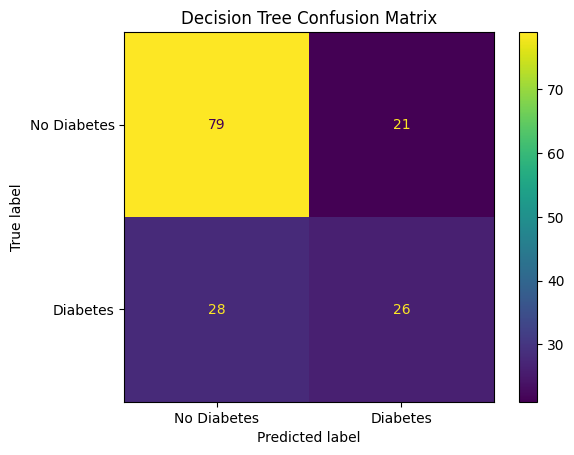

In [17]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()

# 14. Visualize the Decision Tree

One of the major advantages of Decision Trees is interpretability.

The visualization allows us to see:

- Feature used for splitting
- Threshold value
- Gini impurity
- Number of samples
- Class distribution
- Predicted class

This converts the trained model into a visual decision-making process.

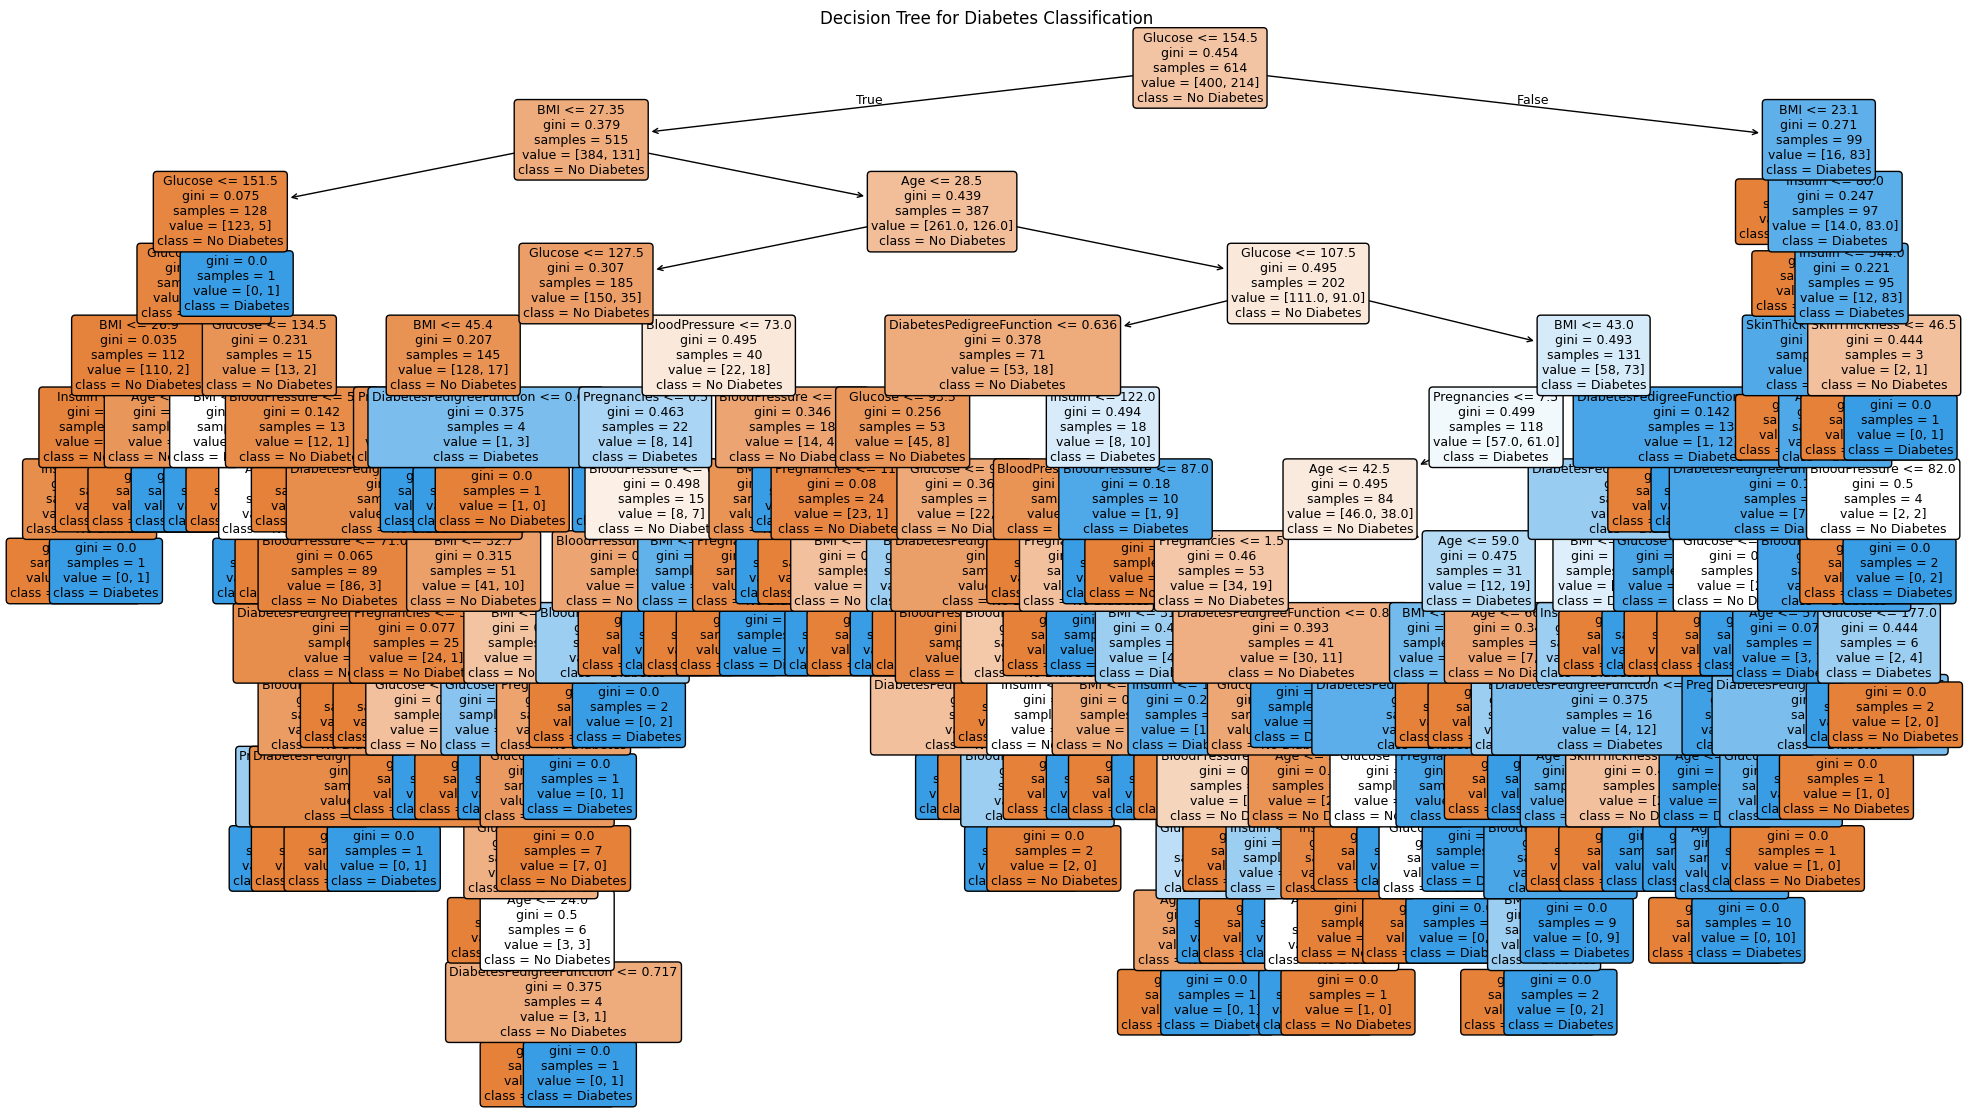

In [18]:
plt.figure(figsize=(24, 14))

plot_tree(
    baseline_tree,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree for Diabetes Classification")
plt.show()

# 15. Extract Human-Readable Decision Rules

A Decision Tree can be converted into text-based rules.

This is useful for understanding how the model transforms clinical features
into predictions.

In [19]:
rules = export_text(
    baseline_tree,
    feature_names=list(X.columns)
)

print(rules)

|--- Glucose <= 154.50
|   |--- BMI <= 27.35
|   |   |--- Glucose <= 151.50
|   |   |   |--- Glucose <= 133.50
|   |   |   |   |--- BMI <= 26.90
|   |   |   |   |   |--- Insulin <= 48.50
|   |   |   |   |   |   |--- Insulin <= 47.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Insulin >  47.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- Insulin >  48.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- BMI >  26.90
|   |   |   |   |   |--- Age <= 44.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Age >  44.00
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- Glucose >  133.50
|   |   |   |   |--- Glucose <= 134.50
|   |   |   |   |   |--- BMI <= 24.85
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- BMI >  24.85
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- Glucose >  134.50
|   |   |   |   |   |--- BloodPressure <= 56.00
|   |   |   |   |   |   |--- Age <= 42.00
|   |   |   |   

### Interpreting the Rules

A rule may look similar to:

    Glucose <= threshold
        AND
    BMI > threshold
        AND
    Age > threshold
        → Diabetes

The exact thresholds are learned automatically from the training data.

This demonstrates the interpretability of Decision Trees:

    Clinical measurements
            ↓
    Threshold-based questions
            ↓
    Recursive decisions
            ↓
    Final classification

# 16. Understanding Tree Depth

Tree depth represents the longest path from the root node to a leaf.

### Shallow Tree

A shallow tree has:

- Fewer rules
- Lower complexity
- Easier interpretation
- Higher risk of underfitting

### Deep Tree

A deep tree has:

- More rules
- Higher complexity
- More detailed decision boundaries
- Higher risk of overfitting

Therefore, tree depth is an important hyperparameter.

In [20]:
depths = [1, 2, 3, 4, 5, 6, 8, 10]

results = []

for depth in depths:

    tree = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    train_predictions = tree.predict(X_train)
    test_predictions = tree.predict(X_test)

    train_accuracy = accuracy_score(
        y_train,
        train_predictions
    )

    test_accuracy = accuracy_score(
        y_test,
        test_predictions
    )

    results.append({
        "Depth": depth,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy
    })

depth_results = pd.DataFrame(results)

depth_results

,Depth,Train Accuracy,Test Accuracy
0,1,0.760586,0.694805
1,2,0.763844,0.688312
2,3,0.768730,0.688312
3,4,0.794788,0.785714
4,5,0.814332,0.759740
5,6,0.850163,0.746753
6,8,0.915309,0.714286
7,10,0.962541,0.675325


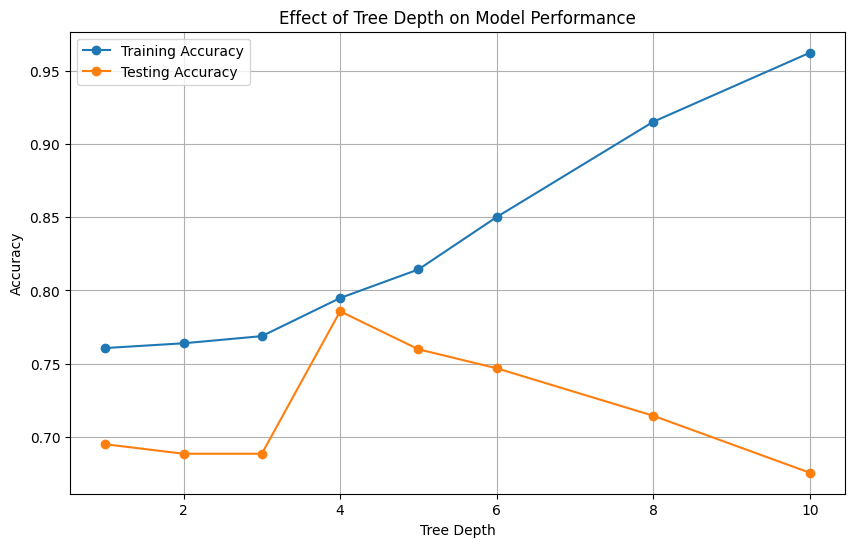

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    depth_results["Depth"],
    depth_results["Train Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depth_results["Depth"],
    depth_results["Test Accuracy"],
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Effect of Tree Depth on Model Performance")
plt.legend()
plt.grid(True)

plt.show()

# 17. Feature Importance

Decision Trees calculate feature importance based on the contribution of
features to impurity reduction throughout the tree.

A high importance score means that the feature contributed substantially to
the tree's splitting decisions.

This does not mean that the feature is medically causal.

In [22]:
feature_importance = pd.Series(
    baseline_tree.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

,0
Glucose,0.355518
BMI,0.178572
Age,0.127095
BloodPressure,0.097661
DiabetesPedigreeFunction,0.092002
Insulin,0.069723
Pregnancies,0.064105
SkinThickness,0.015325


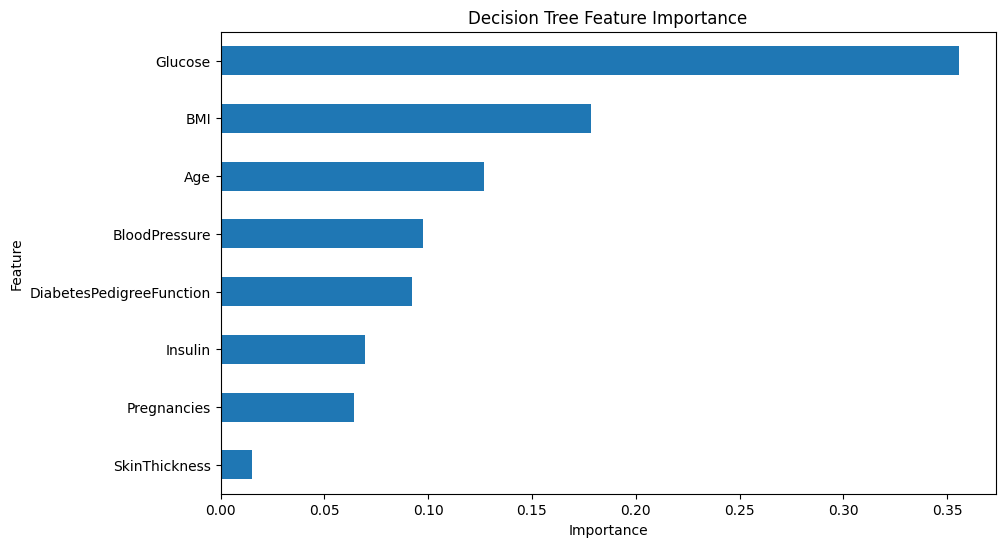

In [23]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")

plt.show()

# 18. Final Model

Based on the tree-depth experiment, we can select a reasonable tree depth
that provides a balance between:

- Predictive performance
- Generalization
- Interpretability
- Model complexity

For this educational project, we will use a controlled maximum depth rather
than allowing the tree to grow without restriction.

In [24]:
final_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

final_tree.fit(X_train, y_train)

final_predictions = final_tree.predict(X_test)

print("Final Decision Tree trained.")
print("Tree depth:", final_tree.get_depth())
print("Number of leaves:", final_tree.get_n_leaves())

Final Decision Tree trained.
Tree depth: 5
Number of leaves: 19


In [25]:
final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    zero_division=0
)

print("Final Model Performance")
print("-" * 30)
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")

Final Model Performance
------------------------------
Accuracy : 0.7597
Precision: 0.6393
Recall   : 0.7222
F1 Score : 0.6783


In [26]:
final_rules = export_text(
    final_tree,
    feature_names=list(X.columns)
)

print(final_rules)

|--- Glucose <= 154.50
|   |--- BMI <= 27.35
|   |   |--- Glucose <= 151.50
|   |   |   |--- Glucose <= 133.50
|   |   |   |   |--- BMI <= 26.90
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- BMI >  26.90
|   |   |   |   |   |--- class: 0
|   |   |   |--- Glucose >  133.50
|   |   |   |   |--- BloodPressure <= 56.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- BloodPressure >  56.00
|   |   |   |   |   |--- class: 0
|   |   |--- Glucose >  151.50
|   |   |   |--- class: 1
|   |--- BMI >  27.35
|   |   |--- Age <= 28.50
|   |   |   |--- Glucose <= 127.50
|   |   |   |   |--- BMI <= 45.40
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- BMI >  45.40
|   |   |   |   |   |--- class: 1
|   |   |   |--- Glucose >  127.50
|   |   |   |   |--- BloodPressure <= 73.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- BloodPressure >  73.00
|   |   |   |   |   |--- class: 0
|   |   |--- Age >  28.50
|   |   |   |--- Glucose <= 107.50
|   |   |   |   |--- DiabetesPedig

# 19. Conclusion

This project implemented a Decision Tree Classifier for diabetes prediction
using clinical measurements.

The model demonstrates how Decision Trees transform numerical clinical data
into interpretable prediction rules.

### Key Findings

- Decision Trees use recursive splitting to divide observations into groups.
- Gini impurity measures the class mixture within each node.
- The algorithm selects splits that improve class separation.
- Each patient follows a path from the root node to a leaf.
- The resulting rules can be represented in human-readable form.
- Tree depth controls model complexity.
- Very shallow trees can underfit the data.
- Very deep trees can overfit the training data.
- Feature importance identifies variables that contributed to the model's
  splitting decisions.
- A controlled tree depth can provide a better balance between complexity and
  generalization.

### Expected Outcome

The Decision Tree demonstrates how a clinical classification problem can be
converted into a sequence of interpretable decision rules.

For example, instead of producing only:

    Prediction = Diabetes

the model can provide a rule-based path involving clinical measurements such
as glucose, BMI, and age.

This interpretability is one of the major advantages of Decision Trees over
many black-box machine learning models.

### Limitation

The model is an educational machine learning implementation. Its predictions
should not be interpreted as medical diagnoses because clinical deployment
would require external validation, appropriate patient populations, clinical
oversight, calibration, fairness assessment, and regulatory validation.